In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor

# `Bagging Ensemble`

### In Bagging Ensemble the core idea is to take samples from the dataset and give those samples to the model, so each model will train on different dataset.

### `Bagging = Bootstraping + Aggregation`

### `Bootstraping` : Taking Random Samples from the dataset and convert them into smaller dataset and fitting it into models.

### `Aggregation` : Making the final prediction. 

## 2 types based on problem :

1. ### Bagging Classification : uses the classification model and for final prediction Majority votes will be selected.
2. ### Bagging Regression : uses the regression model and for final prediction Average of all model's prediction.

---

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
CV_FOLDS = 5
N_ESTIMATORS = 50

## `Bootstraping Types`

1. ### `Bagging` : Row Sampling with Replacement (May repeat rows)
2. ### `Pasting` : Row Sampling without Replacement (no repeatition)
3. ### `Random Subspace` : Columns sampling with Replacement (May repeat columns)
4. ### `Randome Paches` : Columns sampling with Replacement (no repeatition)

In [3]:
# The 4 bootstrap flavors, as BaggingClassifier/Regressor kwargs.
BOOTSTRAP_CONFIGS = {
    "Bagging (rows, w/ replacement)": dict(
        bootstrap=True, max_samples=1.0, bootstrap_features=False, max_features=1.0
    ),
    "Pasting (rows, no replacement)": dict(
        bootstrap=False, max_samples=0.7, bootstrap_features=False, max_features=1.0
    ),
    "Random Subspaces (cols, w/ replacement)": dict(
        bootstrap=False, max_samples=1.0, bootstrap_features=True, max_features=0.5
    ),
    "Random Patches (rows + cols)": dict(
        bootstrap=True, max_samples=0.7, bootstrap_features=True, max_features=0.5
    ),
}

In [5]:
def evaluate_single_vs_bagging(single_model, bagging_model, X, y, scoring, label):
    s_scores = cross_val_score(single_model, X, y, cv=CV_FOLDS, scoring=scoring)
    b_scores = cross_val_score(bagging_model, X, y, cv=CV_FOLDS, scoring=scoring)
    print(f"  {label}")
    print(f"    Single tree      | CV {scoring:6s}: {s_scores.mean():.4f} +/- {s_scores.std():.4f}")
    print(f"    Bagging ensemble | CV {scoring:6s}: {b_scores.mean():.4f} +/- {b_scores.std():.4f}")


def plot_classification_compare(single_model, bagging_model, X, y, title):
    h = 0.03
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    single_model.fit(X, y)
    bagging_model.fit(X, y)
    Z_single = single_model.predict(grid).reshape(xx.shape)
    Z_bag = bagging_model.predict(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, Z, subtitle in zip(axes, [Z_single, Z_bag], ["Single Tree", "Bagging Ensemble"]):
        ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor="k", s=20)
        ax.set_title(subtitle)
        ax.set_xlabel("feature 1")
        ax.set_ylabel("feature 2")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_regression_compare(single_model, bagging_model, X, y, title):
    # X has 2 columns; vary feature 0 across its range, hold feature 1 at its mean
    # so the ensemble/single-tree curves can be drawn as a simple 2-D line plot.
    x0_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 400)
    x1_fixed = np.full_like(x0_line, X[:, 1].mean())
    grid = np.column_stack([x0_line, x1_fixed])

    single_model.fit(X, y)
    bagging_model.fit(X, y)
    y_single = single_model.predict(grid)
    y_bag = bagging_model.predict(grid)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
    for ax, y_line, subtitle in zip(axes, [y_single, y_bag], ["Single Tree", "Bagging Ensemble"]):
        ax.scatter(X[:, 0], y, color="gray", alpha=0.35, s=18, label="data")
        ax.plot(x0_line, y_line, color="black", linewidth=2.5, label=subtitle)
        ax.set_title(subtitle)
        ax.set_xlabel("feature 1 (feature 2 held at its mean)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("y")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Bagging Classification


BAGGING — CLASSIFICATION

--- Bagging (rows, w/ replacement) ---
  Bagging (rows, w/ replacement)
    Single tree      | CV accuracy: 0.8450 +/- 0.0245
    Bagging ensemble | CV accuracy: 0.8650 +/- 0.0242


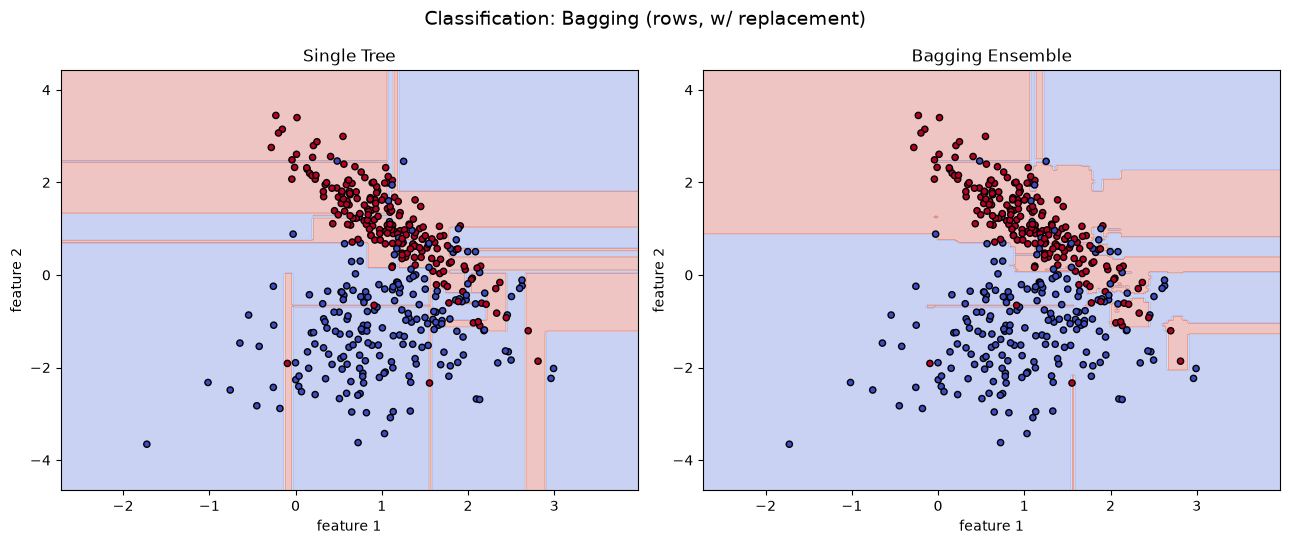


--- Pasting (rows, no replacement) ---
  Pasting (rows, no replacement)
    Single tree      | CV accuracy: 0.8450 +/- 0.0245
    Bagging ensemble | CV accuracy: 0.8675 +/- 0.0203


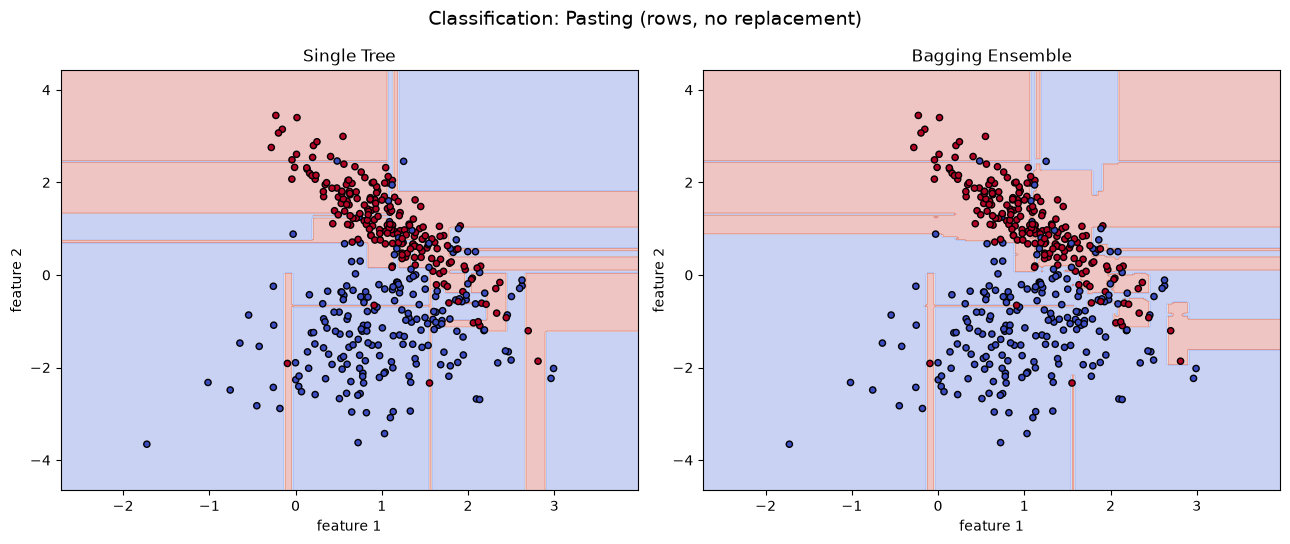


--- Random Subspaces (cols, w/ replacement) ---
  Random Subspaces (cols, w/ replacement)
    Single tree      | CV accuracy: 0.8450 +/- 0.0245
    Bagging ensemble | CV accuracy: 0.5100 +/- 0.0348


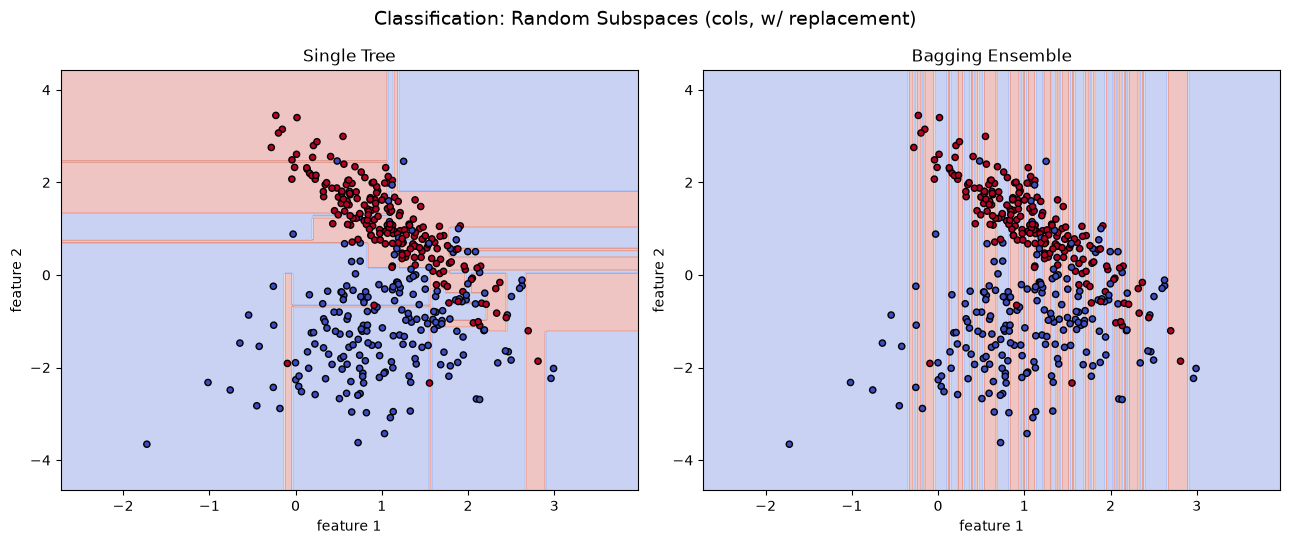


--- Random Patches (rows + cols) ---
  Random Patches (rows + cols)
    Single tree      | CV accuracy: 0.8450 +/- 0.0245
    Bagging ensemble | CV accuracy: 0.7175 +/- 0.0257


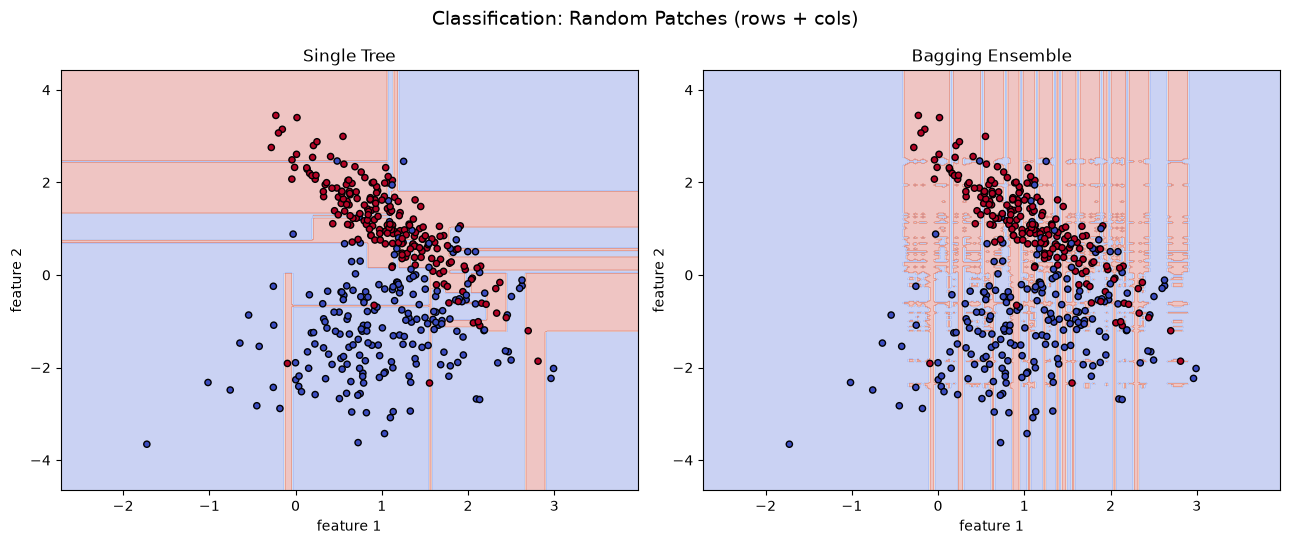

In [6]:
print("\n" + "=" * 72)
print("BAGGING — CLASSIFICATION")
print("=" * 72)

Xc, yc = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.1, flip_y=0.05,
    random_state=RANDOM_STATE,
)

for name, cfg in BOOTSTRAP_CONFIGS.items():
    print(f"\n--- {name} ---")
    single_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
    bagging_clf = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **cfg,
    )
    evaluate_single_vs_bagging(single_tree, bagging_clf, Xc, yc, "accuracy", name)
    plot_classification_compare(single_tree, bagging_clf, Xc, yc, f"Classification: {name}")


## Bagging Regression


BAGGING — REGRESSION

--- Bagging (rows, w/ replacement) ---
  Bagging (rows, w/ replacement)
    Single tree      | CV r2    : 0.8427 +/- 0.0285
    Bagging ensemble | CV r2    : 0.9059 +/- 0.0128


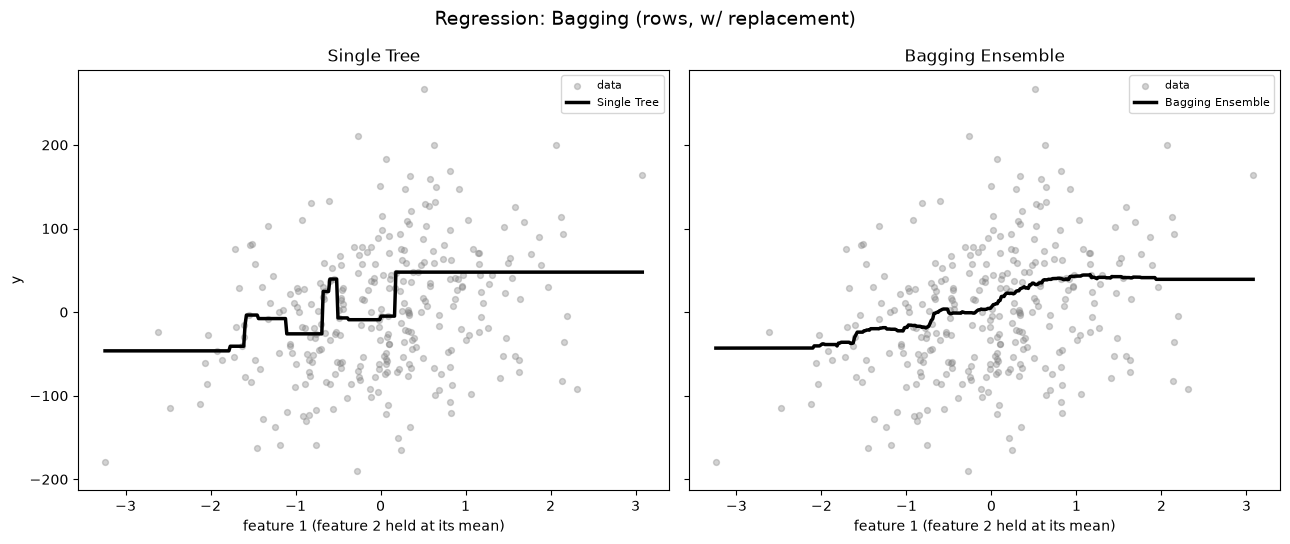


--- Pasting (rows, no replacement) ---
  Pasting (rows, no replacement)
    Single tree      | CV r2    : 0.8427 +/- 0.0285
    Bagging ensemble | CV r2    : 0.8996 +/- 0.0118


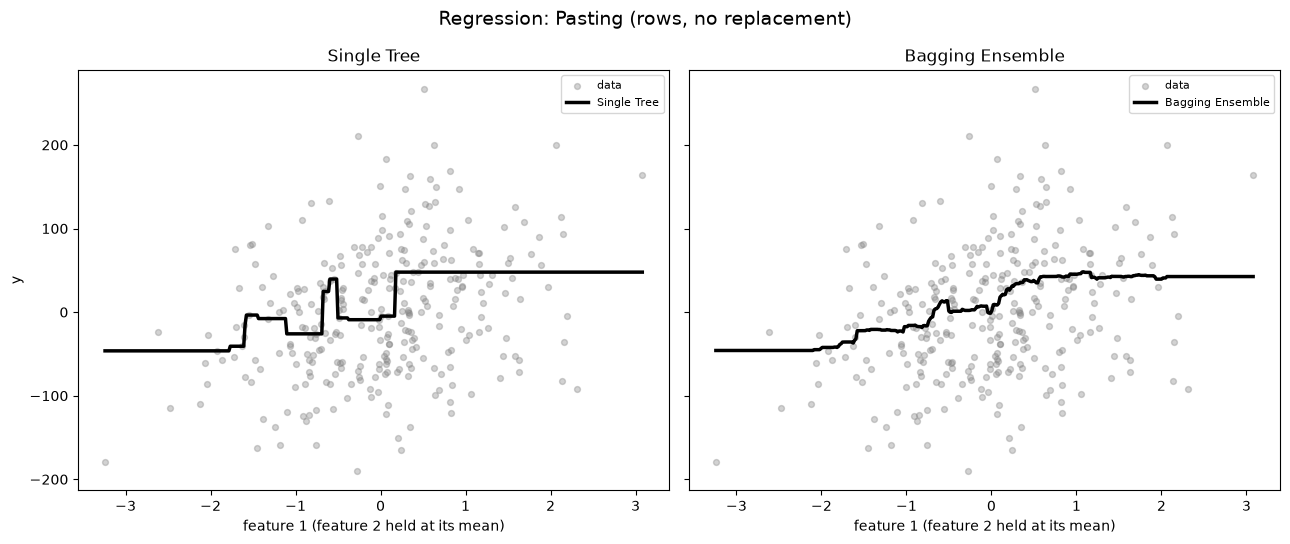


--- Random Subspaces (cols, w/ replacement) ---
  Random Subspaces (cols, w/ replacement)
    Single tree      | CV r2    : 0.8427 +/- 0.0285
    Bagging ensemble | CV r2    : 0.1747 +/- 0.1804


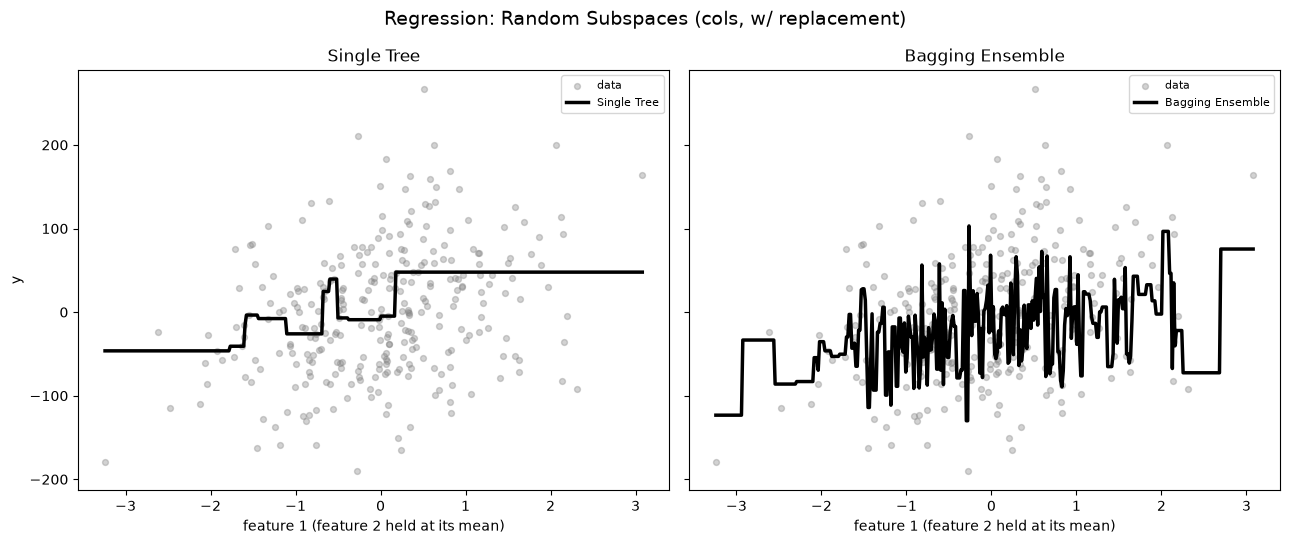


--- Random Patches (rows + cols) ---
  Random Patches (rows + cols)
    Single tree      | CV r2    : 0.8427 +/- 0.0285
    Bagging ensemble | CV r2    : 0.4303 +/- 0.0887


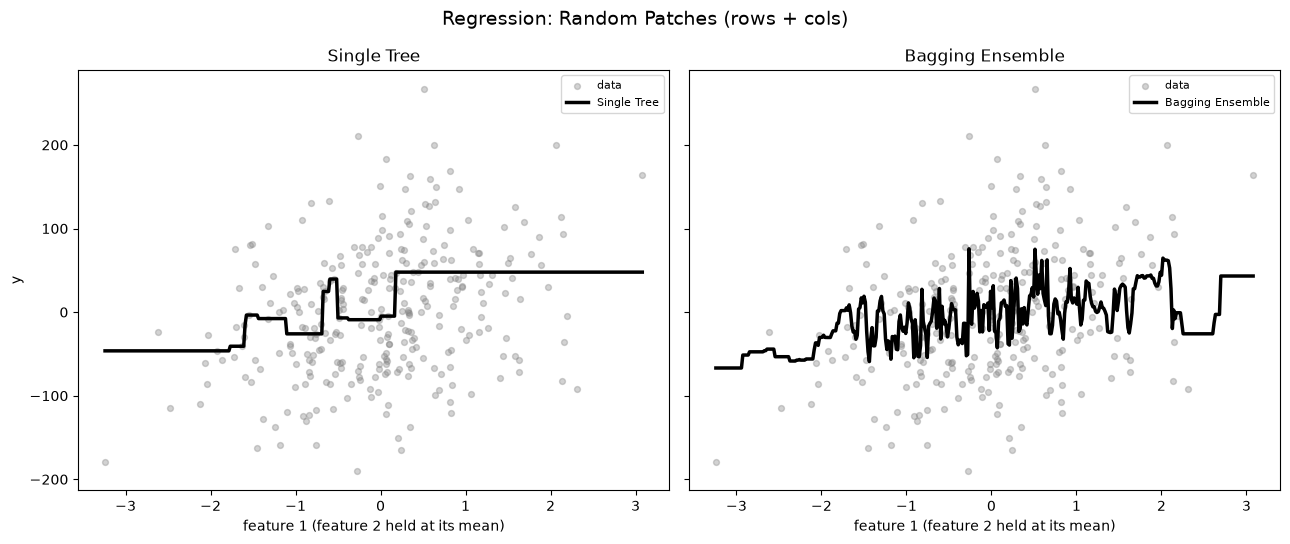


Done.


In [7]:
print("\n" + "=" * 72)
print("BAGGING — REGRESSION")
print("=" * 72)

Xr, yr = make_regression(
    n_samples=300, n_features=2, n_informative=2, noise=18, random_state=RANDOM_STATE
)
# mild nonlinearity so a single tree vs. a bagged forest of trees actually differ
yr = yr + 0.0025 * (Xr[:, 0] ** 3)

for name, cfg in BOOTSTRAP_CONFIGS.items():
    print(f"\n--- {name} ---")
    single_tree_r = DecisionTreeRegressor(random_state=RANDOM_STATE)
    bagging_reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **cfg,
    )
    evaluate_single_vs_bagging(single_tree_r, bagging_reg, Xr, yr, "r2", name)
    plot_regression_compare(single_tree_r, bagging_reg, Xr, yr, f"Regression: {name}")

print("\nDone.")